# Importar librerias necesarias
**Alumno** : Erick Daniel Mamani Calla

**Código** : 2021-119122

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

# Normalizar imágenes

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Cargar datos MNIST

In [3]:
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

classes = [str(i) for i in range(10)]

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 517kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.81MB/s]


# Visualización de imágenes

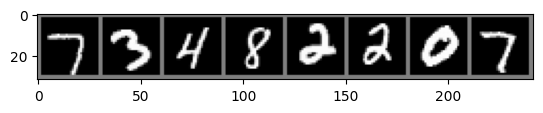

7 3 4 8 2 2 0 7


In [5]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap='gray')
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:8]))
print(' '.join(f'{classes[labels[j]]}' for j in range(8)))

# Modelo CNN

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)  # (1, 28, 28) -> (16, 28, 28)
        self.pool = nn.MaxPool2d(2, 2)                           # (16, 28, 28) -> (16, 14, 14)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1) # (16, 14, 14) -> (32, 14, 14)
        # Después del segundo pool: (32, 7, 7)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Perdida y Optimizador

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Entrenamiento y Validación

In [8]:
def train(model, trainloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    accuracy = 100 * correct / total
    return running_loss / len(trainloader), accuracy


def validate(model, testloader, criterion, device):
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    accuracy = 100 * correct / total
    return val_loss / len(testloader), accuracy


# Entrenamiento

In [9]:
num_epochs = 5

for epoch in range(num_epochs):
    train_loss, train_acc = train(model, trainloader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, testloader, criterion, device)

    print(f"Época {epoch+1}/{num_epochs}")
    print(f" Train Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%")
    print(f" Valid Loss: {val_loss:.4f} | Accuracy: {val_acc:.2f}%\n")


Época 1/5
 Train Loss: 0.2002 | Accuracy: 94.05%
 Valid Loss: 0.0542 | Accuracy: 98.36%

Época 2/5
 Train Loss: 0.0544 | Accuracy: 98.34%
 Valid Loss: 0.0391 | Accuracy: 98.80%

Época 3/5
 Train Loss: 0.0377 | Accuracy: 98.85%
 Valid Loss: 0.0326 | Accuracy: 98.94%

Época 4/5
 Train Loss: 0.0279 | Accuracy: 99.10%
 Valid Loss: 0.0371 | Accuracy: 98.86%

Época 5/5
 Train Loss: 0.0206 | Accuracy: 99.36%
 Valid Loss: 0.0316 | Accuracy: 98.94%



# Guardar modelo

In [10]:
torch.save(model.state_dict(), "model.pth")
print("Modelo guardado como model.pth")

Modelo guardado como model.pth
